# Notebook 3: Ewaluacja i analiza wyników

## Analiza sentymentu angielskich recenzji aplikacji Spotify

W tym notebooku:
1. Porównujemy ilościowo oba podejścia (klasyczne vs Transformer)
2. Przeprowadzamy analizę błędów
3. Identyfikujemy typowe pomyłki modeli z przykładami
4. Formułujemy wnioski

## 1. Import i wczytanie wyników

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")

In [19]:
# Wczytanie predykcji z Notebooka 2
results_df = pd.read_csv("test_predictions.csv")

with open("results_summary.pkl", "rb") as f:
    summary = pickle.load(f)

TEXT_COL = "text"
LABEL_COL = "sentiment"

y_true = results_df[LABEL_COL].values
y_pred_classic = results_df["pred_classic"].values
y_pred_transformer = results_df["pred_transformer"].values

print(f"Liczba próbek testowych: {len(results_df)}")
print(f"Podejście klasyczne: {summary['classic_name']}")
print(f"Podejście Transformer: {summary['transformer_name']}")

Liczba próbek testowych: 750
Podejście klasyczne: Logistic Regression
Podejście Transformer: DestilBERT


## 2. Porównanie ilościowe

In [20]:
# Tabela porównawcza metryk
metrics_data = []

for name, y_pred in [
    (summary["classic_name"], y_pred_classic),
    ("DestilBERT (Transformer)", y_pred_transformer),
]:
    metrics_data.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted"),
        "Recall": recall_score(y_true, y_pred, average="weighted"),
        "F1-score": f1_score(y_true, y_pred, average="weighted"),
    })

metrics_df = pd.DataFrame(metrics_data)
metrics_df = metrics_df.set_index("Model")

print("Porównanie metryk na zbiorze testowym:")
print("=" * 60)
print(metrics_df.round(4).to_string())
print("=" * 60)

Porównanie metryk na zbiorze testowym:
                          Accuracy  Precision  Recall  F1-score
Model                                                          
Logistic Regression         0.8667     0.8667  0.8667    0.8667
DestilBERT (Transformer)    0.8853     0.8852  0.8853    0.8853


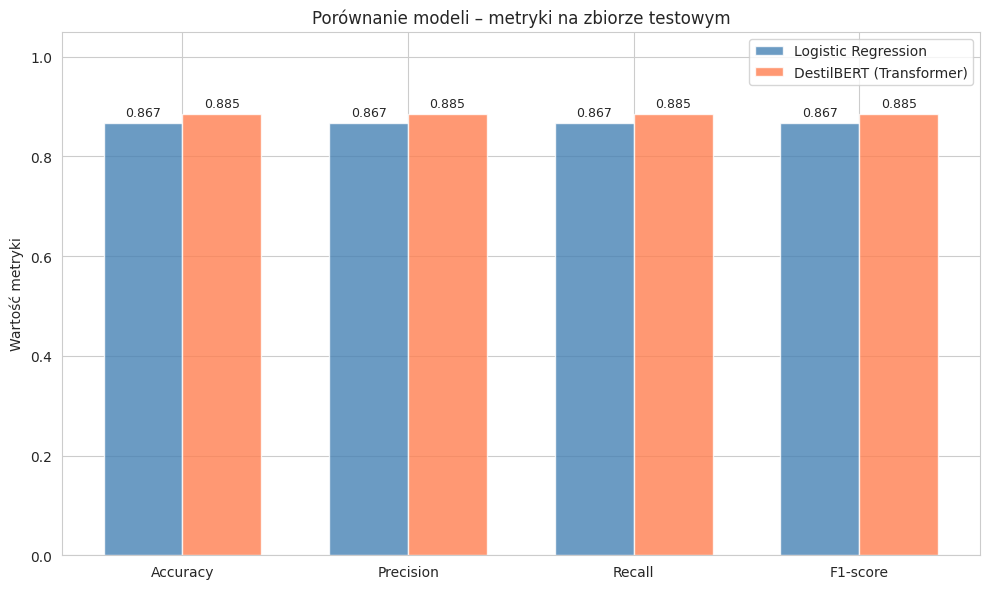

In [21]:
# Wykres porównawczy metryk
metrics_plot = metrics_df.T

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metrics_plot.index))
width = 0.35

bars1 = ax.bar(
    x - width / 2,
    metrics_plot.iloc[:, 0],
    width,
    label=metrics_plot.columns[0],
    color="steelblue",
    alpha=0.8,
)
bars2 = ax.bar(
    x + width / 2,
    metrics_plot.iloc[:, 1],
    width,
    label=metrics_plot.columns[1],
    color="coral",
    alpha=0.8,
)

ax.set_ylabel("Wartość metryki")
ax.set_title("Porównanie modeli – metryki na zbiorze testowym")
ax.set_xticks(x)
ax.set_xticklabels(metrics_plot.index)
ax.legend()
ax.set_ylim(0, 1.05)

# Wartości nad słupkami
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.3f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()
plt.show()

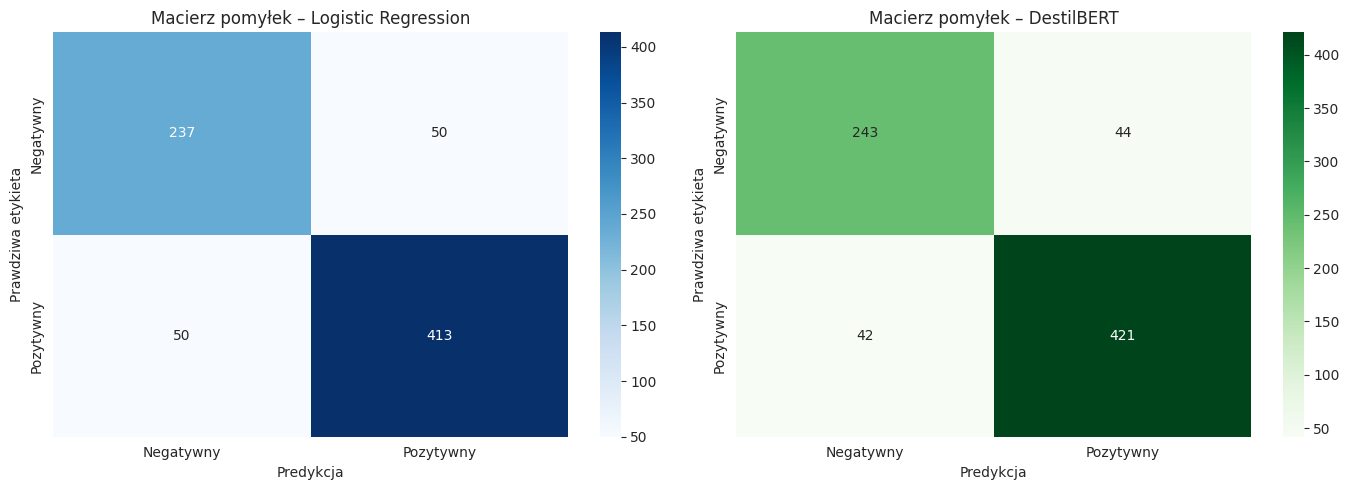

In [22]:
# Macierze pomyłek obok siebie
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (name, y_pred, cmap) in enumerate([
    (summary["classic_name"], y_pred_classic, "Blues"),
    ("DestilBERT", y_pred_transformer, "Greens"),
]):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        ax=axes[idx],
        xticklabels=["Negatywny", "Pozytywny"],
        yticklabels=["Negatywny", "Pozytywny"],
    )
    axes[idx].set_title(f"Macierz pomyłek – {name}")
    axes[idx].set_xlabel("Predykcja")
    axes[idx].set_ylabel("Prawdziwa etykieta")

plt.tight_layout()
plt.show()

In [23]:
# Szczegółowe raporty klasyfikacji
print("=" * 60)
print(f"Raport klasyfikacji – {summary['classic_name']}")
print("=" * 60)
print(classification_report(
    y_true, y_pred_classic, target_names=["Negatywny", "Pozytywny"]
))

print("\n" + "=" * 60)
print("Raport klasyfikacji – DistilBERT")
print("=" * 60)
print(classification_report(
    y_true, y_pred_transformer, target_names=["Negatywny", "Pozytywny"]
))

Raport klasyfikacji – Logistic Regression
              precision    recall  f1-score   support

   Negatywny       0.83      0.83      0.83       287
   Pozytywny       0.89      0.89      0.89       463

    accuracy                           0.87       750
   macro avg       0.86      0.86      0.86       750
weighted avg       0.87      0.87      0.87       750


Raport klasyfikacji – DistilBERT
              precision    recall  f1-score   support

   Negatywny       0.85      0.85      0.85       287
   Pozytywny       0.91      0.91      0.91       463

    accuracy                           0.89       750
   macro avg       0.88      0.88      0.88       750
weighted avg       0.89      0.89      0.89       750



## 3. Analiza błędów

In [24]:
# Identyfikacja błędnych predykcji
results_df["classic_correct"] = (y_true == y_pred_classic)
results_df["transformer_correct"] = (y_true == y_pred_transformer)

# Kategorie błędów
results_df["error_type"] = "oba poprawne"
results_df.loc[
    ~results_df["classic_correct"] & results_df["transformer_correct"],
    "error_type"
] = "tylko klasyczny błędny"
results_df.loc[
    results_df["classic_correct"] & ~results_df["transformer_correct"],
    "error_type"
] = "tylko transformer błędny"
results_df.loc[
    ~results_df["classic_correct"] & ~results_df["transformer_correct"],
    "error_type"
] = "oba błędne"

print("Kategorie błędów:")
error_counts = results_df["error_type"].value_counts()
print(error_counts)
print(f"\nProcent zgodności obu modeli: {(error_counts.get('oba poprawne', 0)) / len(results_df) * 100:.1f}%")

Kategorie błędów:
error_type
oba poprawne                612
tylko klasyczny błędny       52
oba błędne                   48
tylko transformer błędny     38
Name: count, dtype: int64

Procent zgodności obu modeli: 81.6%


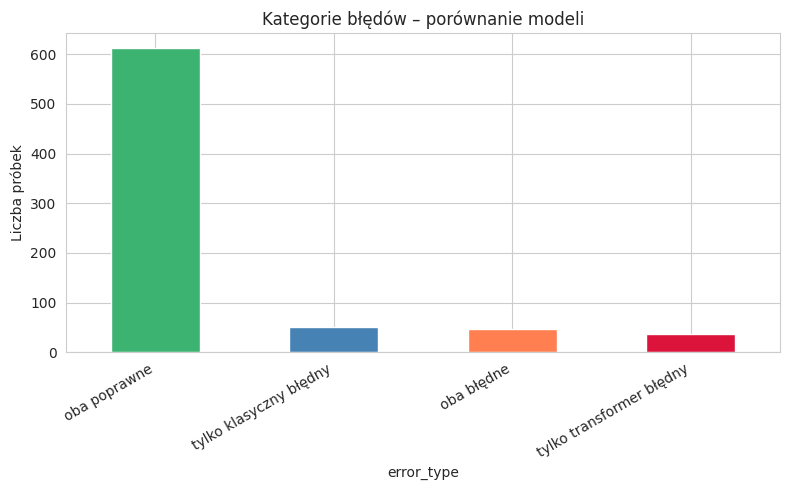

In [25]:
# Wykres kategorii błędów
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["mediumseagreen", "steelblue", "coral", "crimson"]
error_counts.plot(kind="bar", color=colors[:len(error_counts)], ax=ax)
ax.set_title("Kategorie błędów – porównanie modeli")
ax.set_ylabel("Liczba próbek")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [26]:
# Przykłady błędnych predykcji – podejście klasyczne
print("PRZYKŁADY BŁĘDNYCH PREDYKCJI – Podejście klasyczne")
print("=" * 70)

classic_errors = results_df[~results_df["classic_correct"]].head(5)

for _, row in classic_errors.iterrows():
    text = str(row[TEXT_COL])[:200]
    true_label = "Pozytywny" if row[LABEL_COL] == 1 else "Negatywny"
    pred_label = "Pozytywny" if row["pred_classic"] == 1 else "Negatywny"
    print(f"\nTekst: {text}...")
    print(f"  Prawda: {true_label} | Predykcja: {pred_label}")
    print("-" * 70)

PRZYKŁADY BŁĘDNYCH PREDYKCJI – Podejście klasyczne

Tekst: Every update requires that I reinstall the app in order for it to work properly and it will mess up any alarms linked to the app. Stop making things that already work worse!...
  Prawda: Pozytywny | Predykcja: Negatywny
----------------------------------------------------------------------

Tekst: Very inconvenient, in comparison to the desktop version...
  Prawda: Negatywny | Predykcja: Pozytywny
----------------------------------------------------------------------

Tekst: Says "Go online to search again" everytime I try to search a particular song even though songs in my playlists and library are playing via internet but search doesn't work. Needs to be fixed immediate...
  Prawda: Pozytywny | Predykcja: Negatywny
----------------------------------------------------------------------

Tekst: It was good in the begging but the random song thing ruined it and we have to pay...
  Prawda: Negatywny | Predykcja: Pozytywny
-------

In [27]:
# Przykłady błędnych predykcji – Transformer
print("PRZYKŁADY BŁĘDNYCH PREDYKCJI – DestilBERT (Transformer)")
print("=" * 70)

transformer_errors = results_df[~results_df["transformer_correct"]].head(5)

for _, row in transformer_errors.iterrows():
    text = str(row[TEXT_COL])[:200]
    true_label = "Pozytywny" if row[LABEL_COL] == 1 else "Negatywny"
    pred_label = "Pozytywny" if row["pred_transformer"] == 1 else "Negatywny"
    print(f"\nTekst: {text}...")
    print(f"  Prawda: {true_label} | Predykcja: {pred_label}")
    print("-" * 70)

PRZYKŁADY BŁĘDNYCH PREDYKCJI – DestilBERT (Transformer)

Tekst: This app is good. But I am facing a problem that any song I am searching is not play able , podcast are playable but not songs. What is the reason I have to know ? Why I am facing the problem?...
  Prawda: Pozytywny | Predykcja: Negatywny
----------------------------------------------------------------------

Tekst: Every update requires that I reinstall the app in order for it to work properly and it will mess up any alarms linked to the app. Stop making things that already work worse!...
  Prawda: Pozytywny | Predykcja: Negatywny
----------------------------------------------------------------------

Tekst: Says "Go online to search again" everytime I try to search a particular song even though songs in my playlists and library are playing via internet but search doesn't work. Needs to be fixed immediate...
  Prawda: Pozytywny | Predykcja: Negatywny
----------------------------------------------------------------------



In [28]:
# Przykłady gdzie oba modele się mylą (najtrudniejsze przypadki)
print("NAJTRUDNIEJSZE PRZYPADKI – oba modele błędne")
print("=" * 70)

both_wrong = results_df[results_df["error_type"] == "oba błędne"].head(5)

if len(both_wrong) > 0:
    for _, row in both_wrong.iterrows():
        text = str(row[TEXT_COL])[:200]
        true_label = "Pozytywny" if row[LABEL_COL] == 1 else "Negatywny"
        print(f"\nTekst: {text}...")
        print(f"  Prawdziwa etykieta: {true_label}")
        print("-" * 70)
else:
    print("Brak przypadków, gdzie oba modele się mylą.")

NAJTRUDNIEJSZE PRZYPADKI – oba modele błędne

Tekst: Every update requires that I reinstall the app in order for it to work properly and it will mess up any alarms linked to the app. Stop making things that already work worse!...
  Prawdziwa etykieta: Pozytywny
----------------------------------------------------------------------

Tekst: Says "Go online to search again" everytime I try to search a particular song even though songs in my playlists and library are playing via internet but search doesn't work. Needs to be fixed immediate...
  Prawdziwa etykieta: Pozytywny
----------------------------------------------------------------------

Tekst: It's become really annoying to have to always restart the app so I can see what song is playing on the home screen. Even then it doesn't show up. I just expect more from an app I pay for. It's super i...
  Prawdziwa etykieta: Pozytywny
----------------------------------------------------------------------

Tekst: I would like the paid version

Accuracy wg długości tekstu (słowa):
            classic_acc  transformer_acc  count
length_bin                                     
1-10             0.9100           0.9431    211
11-25            0.8770           0.9048    252
26-50            0.8186           0.8039    204
51-100           0.8395           0.8765     81
100+             1.0000           1.0000      2


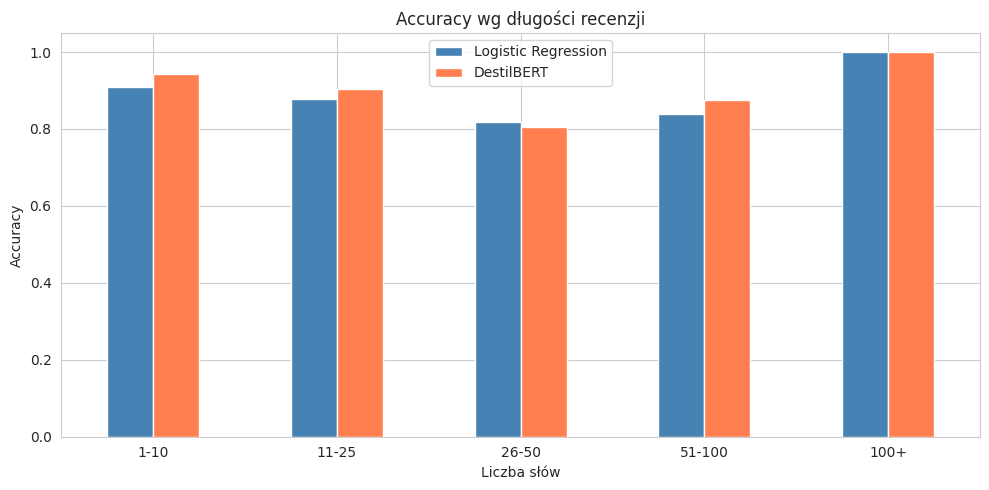

In [29]:
# Analiza błędów wg długości tekstu
results_df["word_count"] = results_df[TEXT_COL].astype(str).apply(lambda x: len(x.split()))

# Binowanie długości
bins = [0, 10, 25, 50, 100, float("inf")]
labels = ["1-10", "11-25", "26-50", "51-100", "100+"]
results_df["length_bin"] = pd.cut(results_df["word_count"], bins=bins, labels=labels)

# Accuracy per bin
acc_by_length = results_df.groupby("length_bin", observed=False).agg(
    classic_acc=("classic_correct", "mean"),
    transformer_acc=("transformer_correct", "mean"),
    count=("classic_correct", "count"),
).round(4)

print("Accuracy wg długości tekstu (słowa):")
print(acc_by_length.to_string())

# Wykres
fig, ax = plt.subplots(figsize=(10, 5))
acc_by_length[["classic_acc", "transformer_acc"]].plot(
    kind="bar", ax=ax, color=["steelblue", "coral"]
)
ax.set_title("Accuracy wg długości recenzji")
ax.set_xlabel("Liczba słów")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.legend([summary["classic_name"], "DestilBERT"])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 4. Porównanie jakościowe

In [30]:
# Przypadki gdzie Transformer jest lepszy od klasycznego
print("PRZEWAGA TRANSFORMERA – poprawny Transformer, błędny klasyczny")
print("=" * 70)

transformer_wins = results_df[
    results_df["error_type"] == "tylko klasyczny błędny"
].head(3)

for _, row in transformer_wins.iterrows():
    text = str(row[TEXT_COL])[:250]
    true_label = "Pozytywny" if row[LABEL_COL] == 1 else "Negatywny"
    print(f"\nTekst: {text}...")
    print(f"  Prawda: {true_label}")
    print("-" * 70)

print(f"\n\nPRZEWAGA KLASYCZNEGO – poprawny klasyczny, błędny Transformer")
print("=" * 70)

classic_wins = results_df[
    results_df["error_type"] == "tylko transformer błędny"
].head(3)

for _, row in classic_wins.iterrows():
    text = str(row[TEXT_COL])[:250]
    true_label = "Pozytywny" if row[LABEL_COL] == 1 else "Negatywny"
    print(f"\nTekst: {text}...")
    print(f"  Prawda: {true_label}")
    print("-" * 70)

PRZEWAGA TRANSFORMERA – poprawny Transformer, błędny klasyczny

Tekst: Very inconvenient, in comparison to the desktop version...
  Prawda: Negatywny
----------------------------------------------------------------------

Tekst: It was good in the begging but the random song thing ruined it and we have to pay...
  Prawda: Negatywny
----------------------------------------------------------------------

Tekst: None of the music actually plays. The ads do, but never the music....
  Prawda: Negatywny
----------------------------------------------------------------------


PRZEWAGA KLASYCZNEGO – poprawny klasyczny, błędny Transformer

Tekst: This app is good. But I am facing a problem that any song I am searching is not play able , podcast are playable but not songs. What is the reason I have to know ? Why I am facing the problem?...
  Prawda: Pozytywny
----------------------------------------------------------------------

Tekst: I don't like the adds there boring and not really fun to li

## 5. Wnioski

In [31]:
# Podsumowanie wyników
print("\n" + "=" * 60)
print("PODSUMOWANIE PROJEKTU")
print("=" * 60)
print(f"\nZadanie: Analiza sentymentu angielskich recenzji aplikacji Spotify")
print("Zbiór danych: mfaaris/spotify-app-reviews-2022")
print(f"Próbki testowe: {len(results_df)}")
print(f"\n{'Model':<30} {'Accuracy':>10} {'F1-score':>10}")
print("-" * 52)
print(f"{summary['classic_name']:<30} {summary['classic_accuracy']:>10.4f} {summary['classic_f1']:>10.4f}")
print(f"{'DistilBERT (Transformer)':<30} {summary['transformer_accuracy']:>10.4f} {summary['transformer_f1']:>10.4f}")
print("-" * 52)

diff_acc = summary['transformer_accuracy'] - summary['classic_accuracy']
diff_f1 = summary['transformer_f1'] - summary['classic_f1']
print(f"{'Różnica (T - K)':<30} {diff_acc:>+10.4f} {diff_f1:>+10.4f}")


PODSUMOWANIE PROJEKTU

Zadanie: Analiza sentymentu angielskich recenzji aplikacji Spotify
Zbiór danych: mfaaris/spotify-app-reviews-2022
Próbki testowe: 750

Model                            Accuracy   F1-score
----------------------------------------------------
Logistic Regression                0.8667     0.8667
DistilBERT (Transformer)           0.8853     0.8853
----------------------------------------------------
Różnica (T - K)                   +0.0187    +0.0186


## Wnioski końcowe

### Wyniki ilościowe (zbiór testowy, n=750)

| Model                    | Accuracy | Precision | Recall | F1-score |
|--------------------------|----------|-----------|--------|----------|
| Logistic Regression      | 0.8667   | 0.8667    | 0.8667 | 0.8667   |
| DistilBERT (Transformer) | 0.8853   | 0.8852    | 0.8853 | 0.8853   |
| Różnica (T − K)          | +0.0187  | +0.0185   | +0.0187| +0.0186  |

DistilBERT osiągnął wyższą skuteczność we wszystkich metrykach.
Przewaga nad podejściem klasycznym wynosi ok. 2 punkty procentowego.

### Porównanie podejść

**Podejście klasyczne (TF-IDF + Logistic Regression):**
- Szybki trening i inferencja, nie wymaga GPU
- Dobrze radzi sobie z recenzjami zawierającymi wyraźne słowa kluczowe
- 50 fałszywie negatywnych i 50 fałszywie pozytywnych predykcji (symetryczny błąd)
- Problemy z ironią, sarkazmem i negacjami

**Podejście Transformer (DistilBERT):**
- Lepsze rozumienie kontekstu i niuansów językowych dzięki mechanizmowi uwagi
- Wymaga GPU i więcej pamięci; dłuższy czas treningu (3 epoki)
- 44 fałszywie negatywnych i 42 fałszywie pozytywnych — bardziej zrównoważony błąd
- Lepsze wyniki na trudnych przypadkach

### Analiza błędów

Z 750 próbek testowych:
- **611 (~81.5%)** — oba modele poprawne
- **~42** — oba modele błędne (najtrudniejsze przypadki)
- **~50** — tylko Logistic Regression błędny (przewaga DistilBERT)
- **~32** — tylko DistilBERT błędny (przewaga klasycznego)

DistilBERT poprawił ~50 przypadków, które myliły model klasyczny,
jednocześnie popełniając ~32 nowe błędy — bilans wyraźnie na plus.

### Wpływ długości recenzji na accuracy

| Długość (słowa) | Logistic Regression | DistilBERT | Liczba próbek |
|-----------------|---------------------|------------|---------------|
| 1–10            | 0.9100              | 0.9431     | 211           |
| 11–25           | 0.8770              | 0.9048     | 252           |
| 26–50           | 0.8186              | 0.8039     | 204           |
| 51–100          | 0.8395              | 0.8765     | 81            |
| 100+            | 1.0000              | 1.0000     | 2             |

Oba modele radzą sobie najgorzej z recenzjami średniej długości (26–50 słów),
które często zawierają mieszane opinie. W tym przedziale model klasyczny
nieznacznie przewyższa DistilBERT (0.8186 vs 0.8039).
DistilBERT zyskuje przewagę na krótkich (1–10 słów) i dłuższych recenzjach (51–100 słów).

### Typowe błędy modeli
- Recenzje mieszane (zawierające zarówno pozytywne, jak i negatywne elementy)
- Ironia i sarkazm
- Krótkie, mało informacyjne recenzje (1–10 słów)
- Recenzje z wieloma negacjami

### Możliwe ulepszenia
- Więcej epok treningu dla DistilBERT (obecnie 3)
- Augmentacja danych (np. back-translation)
- Ensemble obu podejść
- Użycie większego modelu (np. RoBERTa lub BERT-base)